In [1]:
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, root_mean_squared_error, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("processed_titanic_without_normalization.csv")
df.head(5)

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,num,HomePlanet_Europa,...,Destination_TRAPPIST-1e,VIP_True,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,side_S
0,0001_01,39.0,0.0,0.0,0.0,0.0,0.0,False,0.0,True,...,True,False,True,False,False,False,False,False,False,False
1,0002_01,24.0,109.0,9.0,25.0,549.0,44.0,True,0.0,False,...,True,False,False,False,False,False,True,False,False,True
2,0003_01,58.0,43.0,3576.0,0.0,6715.0,49.0,False,0.0,True,...,True,True,False,False,False,False,False,False,False,True
3,0003_02,33.0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,True,...,True,False,False,False,False,False,False,False,False,True
4,0004_01,16.0,303.0,70.0,151.0,565.0,2.0,True,1.0,False,...,True,False,False,False,False,False,True,False,False,True


In [3]:
# Regression

In [4]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['VRDeck'], axis=1), df['VRDeck'], test_size=0.4, random_state=42)
x_train.head(5)

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,Transported,num,HomePlanet_Europa,HomePlanet_Mars,...,Destination_TRAPPIST-1e,VIP_True,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,side_S
4475,4757_01,24.0,185.0,0.0,476.0,1810.0,False,896.0,False,False,...,True,False,False,False,False,False,True,False,False,True
7118,7585_02,39.0,8209.0,18.0,432.0,3560.0,False,281.0,True,False,...,True,False,False,True,False,False,False,False,False,True
7212,7705_01,46.0,5888.0,0.0,13.0,12.0,False,1470.0,False,True,...,True,False,False,False,False,False,True,False,False,True
6982,7422_01,21.0,550.0,0.0,61.0,4.0,False,1204.0,False,False,...,True,False,False,False,False,False,False,True,False,True
8248,8813_01,41.0,413.0,0.0,0.0,7.0,False,1421.0,False,False,...,False,False,False,False,False,False,False,True,False,True


896.6433521227765


count     8693.000000
mean       298.261820
std       1134.126417
min          0.000000
25%          0.000000
50%          0.000000
75%         40.000000
max      24133.000000
Name: VRDeck, dtype: float64

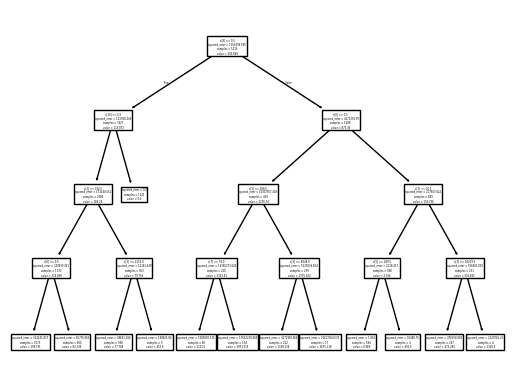

In [5]:
dt_regressor_model = DecisionTreeRegressor(max_depth=4)

dt_regressor_model.fit(x_train, y_train)

y_pred = dt_regressor_model.predict(x_test)

tree.plot_tree(dt_regressor_model)

rmse = root_mean_squared_error(y_test, y_pred)
print(rmse)
df['VRDeck'].describe()

In [6]:
# Classification

In [7]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['Transported'], axis=1), df['Transported'], test_size=0.4, random_state=42)
x_train.head()

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,num,HomePlanet_Europa,HomePlanet_Mars,...,Destination_TRAPPIST-1e,VIP_True,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,side_S
4475,4757_01,24.0,185.0,0.0,476.0,1810.0,53.0,896.0,False,False,...,True,False,False,False,False,False,True,False,False,True
7118,7585_02,39.0,8209.0,18.0,432.0,3560.0,54.0,281.0,True,False,...,True,False,False,True,False,False,False,False,False,True
7212,7705_01,46.0,5888.0,0.0,13.0,12.0,0.0,1470.0,False,True,...,True,False,False,False,False,False,True,False,False,True
6982,7422_01,21.0,550.0,0.0,61.0,4.0,5.0,1204.0,False,False,...,True,False,False,False,False,False,False,True,False,True
8248,8813_01,41.0,413.0,0.0,0.0,7.0,347.0,1421.0,False,False,...,False,False,False,False,False,False,False,True,False,True


0.8369738210336642


Text(0.5, 1.0, 'ROC curve')

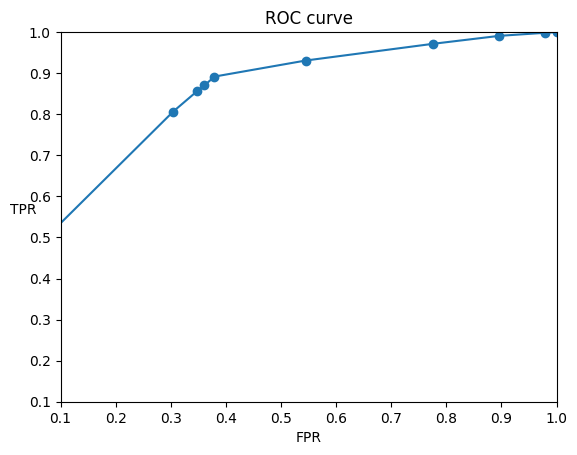

In [12]:
dt_classifier_model = DecisionTreeClassifier(max_depth=4)

dt_classifier_model.fit(x_train, y_train)

y_pred = dt_classifier_model.predict_proba(x_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred[:, 1])

print(auc(fpr, tpr))

plt.plot(fpr, tpr, marker='o')
plt.xlim(0.1, 1)
plt.ylim(0.1, 1)
plt.xlabel('FPR')
plt.ylabel('TPR', rotation=0)
plt.title('ROC curve')

In [9]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

       False       0.81      0.65      0.72      1714
        True       0.72      0.86      0.78      1764

    accuracy                           0.76      3478
   macro avg       0.77      0.75      0.75      3478
weighted avg       0.77      0.76      0.75      3478

